In [2]:
import numpy as np

array_length = 1000

true_elements = 10

prior_array = np.full(array_length, False, dtype=bool)

prior_array[:true_elements] = True

np.random.shuffle(prior_array)

In [3]:

array_length = 100
true_elements = 95
likelihood_array = np.full(array_length, True, dtype=bool)

likelihood_array[:5] = False

np.random.shuffle(likelihood_array)



In [4]:
population_size = 1000
 
prior_array = np.array([False] * 990 + [True] * 10)

sampled_population = np.random.choice(prior_array, size=population_size)


count_with_disease = np.sum(sampled_population)
count_without_disease = population_size - count_with_disease

print("Number of individuals with disease:", count_with_disease)
print("Number of individuals without disease:", count_without_disease)

Number of individuals with disease: 10
Number of individuals without disease: 990


In [5]:


population_size = 1000

prior_array = np.array([False] * 990 + [True] * 10)

count_with_disease = 0
count_without_disease = 0

for i in range(population_size):
   
    person_has_disease = np.random.choice(prior_array)
    

    if person_has_disease:
       count_with_disease += 1
    else:
       count_without_disease += 1



print("Number of individuals with disease:", count_with_disease)
print("Number of individuals without disease:", count_without_disease)



Number of individuals with disease: 7
Number of individuals without disease: 993


In [6]:
population_size = 1000
prior_array = np.array([False] * 990 + [True] * 10)
likelihood_array = np.array([True] * 95 + [False] * 5)

sampled_population = np.random.choice(prior_array, size=population_size)


true_positives = 0
false_positives = 0


for person in sampled_population:
    if person:
       
        test_result = np.random.choice(likelihood_array)
        if test_result:
            true_positives += 1
    else:
     
        test_result = not np.random.choice(likelihood_array)
        if test_result:
            false_positives += 1


total_positives = true_positives + false_positives


posterior_probability = true_positives / total_positives if total_positives > 0 else 0

# Print the results
print("True Positives (TP):", true_positives)
print("False Positives (FP):", false_positives)
print("Total Positives (P):", total_positives)
print("Posterior Probability:", posterior_probability * 100, "%")

True Positives (TP): 9
False Positives (FP): 49
Total Positives (P): 58
Posterior Probability: 15.517241379310345 %


In [7]:
population_size = 1000

iterations = 10

priors = np.linspace(0.01, 0.02, 10)  
tprs = np.linspace(0.90, 0.95, 10)   
fprs = np.linspace(0.05, 0.10, 10)    

posterior_probabilities = np.zeros(iterations)

for k in range(iterations):
    
    prior_probability = np.random.choice(priors)
    tpr = np.random.choice(tprs)
    fpr = np.random.choice(fprs)
    
    
    prior_array = np.random.choice([True, False], size=population_size, p=[prior_probability, 1 - prior_probability])
    
    
    true_positives = 0
    false_positives = 0
    
    
    for person_has_disease in prior_array:
        if person_has_disease: 
            if np.random.rand() < tpr:
                true_positives += 1
        else:  
            if np.random.rand() < fpr:
                false_positives += 1
                

    total_positives = true_positives + false_positives
    
   
    posterior_probability = true_positives / total_positives if total_positives > 0 else 0
    posterior_probabilities[k] = posterior_probability

print("Posterior probabilities for each iteration:")
print(posterior_probabilities * 100, "%")

Posterior probabilities for each iteration:
[ 7.05882353 14.44444444 14.86486486  9.7826087  13.88888889 11.86440678
 11.32075472 27.90697674 14.28571429 19.13043478] %


Mean of posterior probabilities: 0.14454791773241332
Median of posterior probabilities: 0.14087301587301587
Mode of posterior probabilities: ModeResult(mode=array([0.07058824]), count=array([1]))
Standard deviation of posterior probabilities: 0.054442808706180346


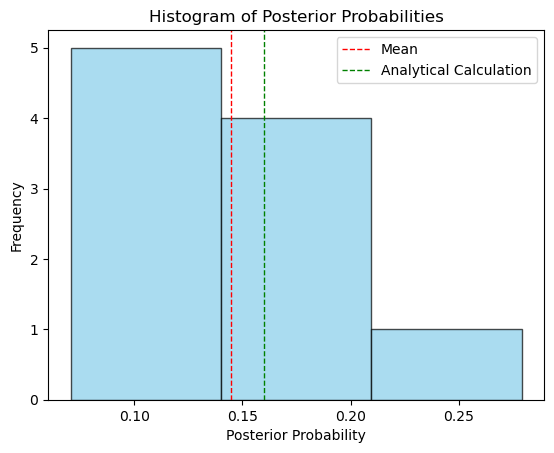

In [8]:
from scipy import stats
import matplotlib.pyplot as plt


mean_posterior = np.mean(posterior_probabilities)
median_posterior = np.median(posterior_probabilities)
mode_posterior = stats.mode(posterior_probabilities, keepdims=True)
std_dev_posterior = np.std(posterior_probabilities)

analytical_calculation_value = 0.16

print("Mean of posterior probabilities:", mean_posterior)
print("Median of posterior probabilities:", median_posterior)
print("Mode of posterior probabilities:", mode_posterior)
print("Standard deviation of posterior probabilities:", std_dev_posterior)


plt.hist(posterior_probabilities, bins=3, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=mean_posterior, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(x=analytical_calculation_value, color='green', linestyle='dashed', linewidth=1, label='Analytical Calculation')


plt.title('Histogram of Posterior Probabilities')
plt.xlabel('Posterior Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

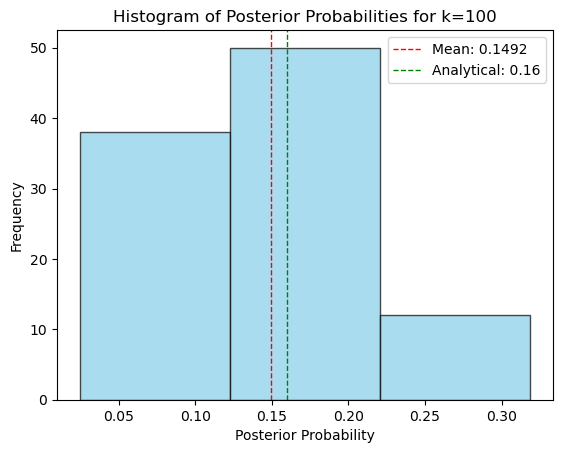

Summary for k=100:
Mean: 0.14924551846669287
Median: 0.14519104084321477
Mode: ModeResult(mode=array([0.15116279]), count=array([3]))
Standard Deviation: 0.05535887442414537


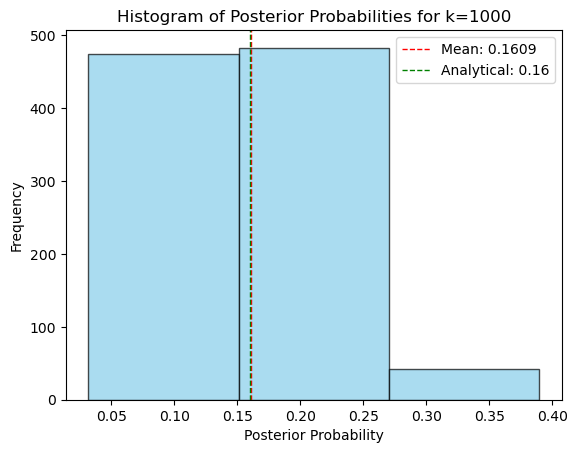

Summary for k=1000:
Mean: 0.1608601799355087
Median: 0.15384615384615385
Mode: ModeResult(mode=array([0.2]), count=array([18]))
Standard Deviation: 0.06015962510480437


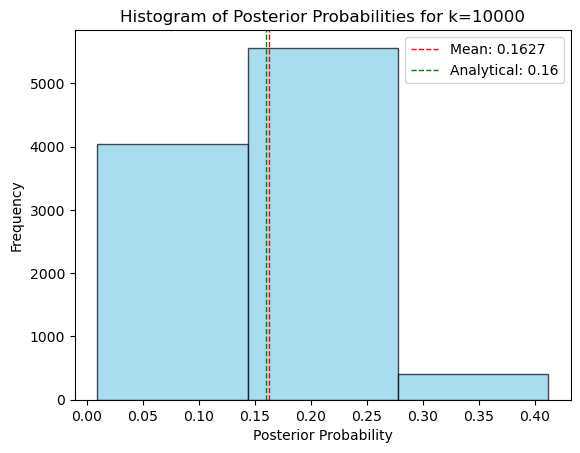

Summary for k=10000:
Mean: 0.16270197712424733
Median: 0.1568627450980392
Mode: ModeResult(mode=array([0.16666667]), count=array([132]))
Standard Deviation: 0.05834532034381616


In [10]:
def simulate_and_summarize_optimized(k_range, analytical_calculation_value):
    
    posterior_probabilities = np.zeros(k_range)
    
    priors = np.linspace(0.01, 0.02, 10)
    tprs = np.linspace(0.90, 0.95, 10)
    fprs = np.linspace(0.05, 0.10, 10)
    
    for k in range(k_range):
        sampled_prior = np.random.choice(priors)
        sampled_trp = np.random.choice(tprs)
        sampled_fpr = np.random.choice(fprs)
        
        disease_status = np.random.choice([True, False], size=1000, p=[sampled_prior, 1-sampled_prior])
        
       
        disease_positive = np.random.rand(population_size) < sampled_trp
        false_positive = np.random.rand(population_size) < sampled_fpr
        
        test_outcomes = np.where(disease_status, disease_positive, false_positive)

      
        true_positives = np.sum(disease_status & test_outcomes)
        false_positives = np.sum(~disease_status & test_outcomes)
        
        total_positives = true_positives + false_positives
        
        posterior_probability = true_positives / total_positives if total_positives > 0 else 0
        posterior_probabilities[k] = posterior_probability

    mean_posterior = np.mean(posterior_probabilities)
    median_posterior = np.median(posterior_probabilities)
    mode_posterior = stats.mode(posterior_probabilities, keepdims=True)
    std_dev_posterior = np.std(posterior_probabilities)

    plt.hist(posterior_probabilities, bins=3, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=mean_posterior, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_posterior:.4f}')
    plt.axvline(x=analytical_calculation_value, color='green', linestyle='dashed', linewidth=1, label=f'Analytical: {analytical_calculation_value:.2f}')
    plt.title(f'Histogram of Posterior Probabilities for k={k_range}')
    plt.xlabel('Posterior Probability')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    print(f"Summary for k={k_range}:")
    print("Mean:", mean_posterior)
    print("Median:", median_posterior)
    print("Mode:", mode_posterior)
    print("Standard Deviation:", std_dev_posterior)


analytical_calculation_value = 0.16  
simulate_and_summarize_optimized(100, analytical_calculation_value)
simulate_and_summarize_optimized(1000, analytical_calculation_value)
simulate_and_summarize_optimized(10000, analytical_calculation_value)

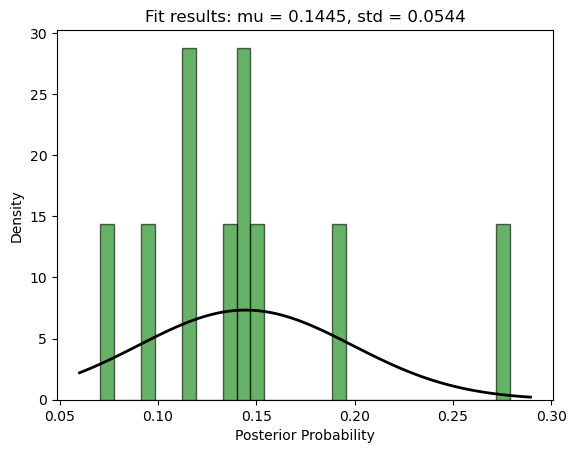

In [12]:
from scipy.stats import norm

mu, std = norm.fit(posterior_probabilities)
plt.hist(posterior_probabilities, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')

xmin, xmax = plt.xlim() 
x = np.linspace(xmin, xmax, 100)  
p = norm.pdf(x, mu, std)  

plt.plot(x, p, 'k', linewidth=2)  
title = "Fit results: mu = %.4f, std = %.4f" % (mu, std)
plt.title(title)
plt.xlabel('Posterior Probability')
plt.ylabel('Density')

plt.show()